In [64]:
'''
Logistic Regression
-------------------------------------------------
-Used for binary classification.
-Uses sigmoid function to predict data.
-Sigmoid Function and AUC-ROC Curve.

-Train Test Split
-> Stratification (Stratify) -> to remove biasness in target
train_test_split(
    X,Y, test_size=0.2, random_state=42, stratify=Y
)

Logistic Model Arguments
----------------------------------------------------------------------------------------------
solver = liblinear(small sized data), lbfgs(medium sized data)(default), saga(large sized data)
lbfgs-> Limited Memory BFGS
class_weight = None(default), balanced
random_state = None(default),index

Classification Metrics
-----------------------------------------------------------------------------------------------
1. Classification Report
2. Confusion Matrix

'''

'\nLogistic Regression\n-------------------------------------------------\n-Used for binary classification.\n-Uses sigmoid function to predict data.\n-Sigmoid Function and AUC-ROC Curve.\n\n-Train Test Split\n-> Stratification (Stratify) -> to remove biasness in target\ntrain_test_split(\n    X,Y, test_size=0.2, random_state=42, stratify=Y\n)\n\nLogistic Model Arguments\n----------------------------------------------------------------------------------------------\nsolver = liblinear(small sized data), lbfgs(medium sized data)(default), saga(large sized data)\nlbfgs-> Limited Memory BFGS\nclass_weight = None(default), balanced\nrandom_state = None(default),index\n\nClassification Metrics\n-----------------------------------------------------------------------------------------------\n1. Classification Report\n2. Confusion Matrix\n\n'

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Train Test Split
from sklearn.model_selection import train_test_split
# Feature Scaling
from sklearn.preprocessing import StandardScaler
# Classificcation Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [66]:
df = pd.read_csv('D:\Data Science\Dataset\Cardiovascular_Disease.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Acer\AppData\Local\Temp\ipykernel_12200\3559409921.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\Data Science\Dataset\Cardiovascular_Disease.csv')


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [68]:
df['age'] = df['age']//365
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [69]:
columns = ['age','height','weight','ap_hi','ap_lo']
for col in columns:
    skew_val = df[col].skew()
    print(f'{col}:{skew_val}')

age:-0.30574389867589913
height:-0.6421874521557643
weight:1.0120701082089065
ap_hi:85.29621385553034
ap_lo:32.114082834816884


<Axes: ylabel='ap_hi'>

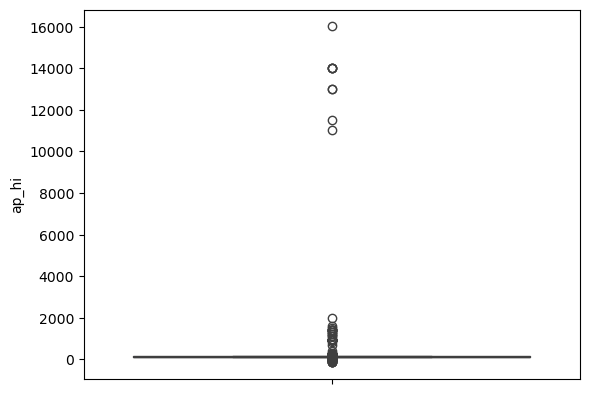

In [70]:
sns.boxplot(df['ap_hi'])

<Axes: ylabel='ap_hi'>

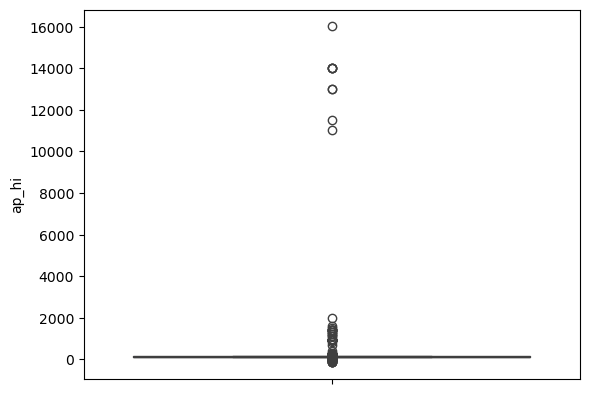

In [71]:
sns.boxplot(df['ap_hi'])

<Axes: ylabel='height'>

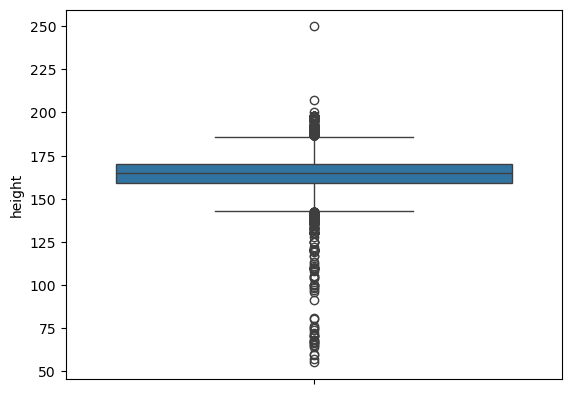

In [72]:
sns.boxplot(df['height'])

<Axes: ylabel='weight'>

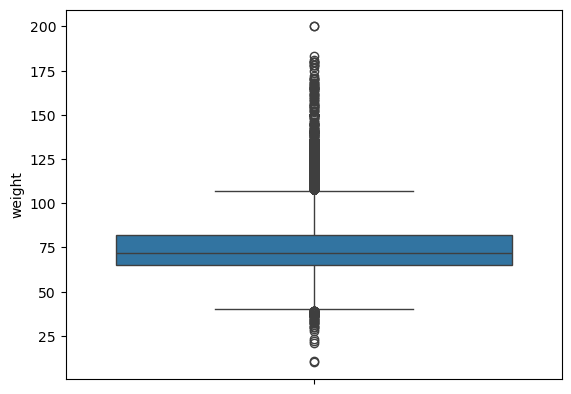

In [73]:
sns.boxplot(df['weight'])

In [74]:
df['age'].min()

29

In [75]:
filtered_df=df[
    (df['height'].between(150,198))&
    (df['weight'].between(45,110))&
    (df['ap_hi'].between(90,180))&
    (df['ap_lo'].between(50,90))
]

## Feature and Target

In [76]:
features =['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target='cardio'

In [77]:
X=filtered_df[features]
Y=filtered_df[target]

## Train Test Split

In [78]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

## Feature Scaling

In [79]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Model Implementation

In [80]:
model = LogisticRegression(
    solver='lbfgs', class_weight='balanced', random_state=42
)
model.fit(X_train_scale, Y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [81]:
Y_pred = model.predict(X_test_scale)
Y_pred

array([1, 0, 0, ..., 1, 0, 0], dtype=int64)

## Metrics

In [82]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [83]:
'''
Macro Avg
-----------------------------
(p1 + p2 + ....pn)/n

Weighted AVg
-----------------------------
((p1*sup)+(p2*sup)+...+(pn*sup))/total_support
'''

'\nMacro Avg\n-----------------------------\n(p1 + p2 + ....pn)/n\n\nWeighted AVg\n-----------------------------\n((p1*sup)+(p2*sup)+...+(pn*sup))/total_support\n'

In [84]:
print(cr)

              precision    recall  f1-score   support

           0       0.72      0.77      0.75      6532
           1       0.71      0.66      0.68      5667

    accuracy                           0.72     12199
   macro avg       0.72      0.71      0.71     12199
weighted avg       0.72      0.72      0.72     12199



In [85]:
print(cm)

[[5044 1488]
 [1949 3718]]


In [86]:
cm.ravel().sum()

12199

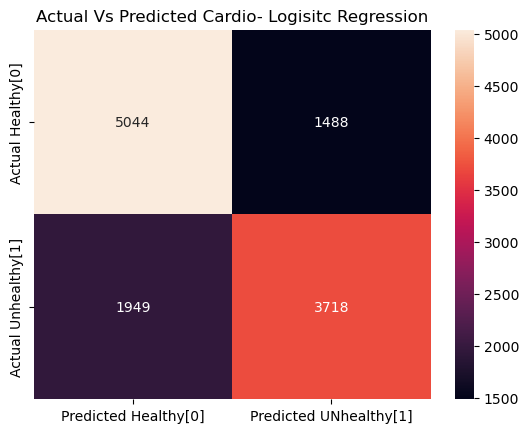

In [87]:
sns.heatmap(cm, annot=True, fmt='1.0f', xticklabels=['Predicted Healthy[0]', 'Predicted UNhealthy[1]'],
            yticklabels=['Actual Healthy[0]', 'Actual Unhealthy[1]'])
plt.title('Actual Vs Predicted Cardio- Logisitc Regression')
plt.show()

# AUC-ROC Curve

In [88]:
'''
Process of calculating AUC-ROC Curve
---------------------------------------
1. Calculate Probability
2. Calculate TP rate and FP rate
    -> tpr = tp/(tp-fn)
    -> fpr = fp/(fp-tn)
3. Best Threshold Position
    -> Using J Score (tpr-fpr)
'''

'\nProcess of calculating AUC-ROC Curve\n---------------------------------------\n1. Calculate Probability\n2. Calculate TP rate and FP rate\n    -> tpr = tp/(tp-fn)\n    -> fpr = fp/(fp-tn)\n3. Best Threshold Position\n    -> Using J Score (tpr-fpr)\n'

In [89]:
# Probability
Y_prob = model.predict_proba(X_test_scale)[:,1]
Y_prob

array([0.90541678, 0.10973616, 0.2811203 , ..., 0.88364896, 0.48971205,
       0.42707347])

In [90]:
# Calculate tpr and fpr
# Used to find threshold for roc auc curve
tn, fp, fn, tp = cm.ravel()
tpr_default = tp/(tp-fn)
fpr_default = fp/(fp-tn)

print(f'True positive rate: {tpr_default}')
print(f'False Positive rate: {fpr_default}')

True positive rate: 2.101752402487281
False Positive rate: -0.4184476940382452


In [91]:
# Find best position for TPR, FPR and Threshold
fpr, tpr, threshold = roc_curve(Y_test, Y_prob)
auc_score = roc_auc_score(Y_test, Y_prob)

print(f'AUC Score: {auc_score}')

AUC Score: 0.776445258272153


In [92]:
j_score = tpr - fpr
best_idx = np.argmax(j_score)

best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]
best_threshold = threshold[best_idx]

Best Threshold: 0.4829553904416225


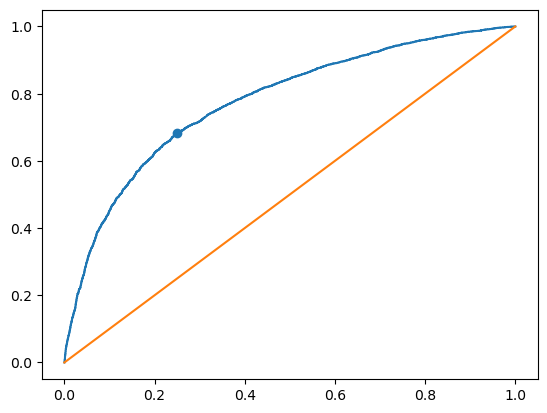

In [93]:
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.scatter(best_fpr, best_tpr)
print(f'Best Threshold: {best_threshold}')